# 14.5.1 守恒、正性与离散步长

## 学习目标与先修知识

用矩阵（matrix）的列和与非对角符号检查闭合交换，辨认 Euler 步长造成的非负性（nonnegativity）失效。

先修：11.2 网络扩散与拉普拉斯；14.1 投影（projection）误差；14.2 传播矩阵。

## 具体问题

两个候选矩阵都能在有限数据上画出平滑曲线，哪些条件能让它们代表无输入（input）的闭合物质交换？一步显式计算是否仍保持非负？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

在二室模型（model）上分别改变一项交换系数，直接计算各列之和。

In [2]:
good=np.array([[-1.,.2],[1.,-.2]]);bad=np.array([[-1.,.3],[1.,-.2]])
print('闭合交换列和',good.sum(axis=0),'；偏差模型列和',bad.sum(axis=0))

闭合交换列和 [0. 0.] ；偏差模型列和 [0.  0.1]


## 模型假设

状态（state）是各室所追踪物质总量（tracked amount） U，时间单位 T，无外部输入与清除。方程为 $\dot x=Ax$；下面的正性指任意非负初态沿连续时间解仍非负，不代表某一个含误差的轨迹（trajectory）恰好未变负。

## 数学解释与推导

总量 $M=\mathbf1^\mathsf Tx$ 的导数（derivative）是 $\dot M=\mathbf1^\mathsf T Ax$。对所有初态守恒需每列和为零；闭合交换的非对角元 $A_{ij}\ge0$，这使 $A$ 为 Metzler 矩阵，连续时间正锥保持。显式 Euler 一步为 $(I+hA)x$；要使任意非负 $x$ 的下一步仍非负，还需对角元 $1+hA_{ii}\ge0$。这些是本题坐标下的结构条件；浓度（concentration）坐标或外部输入下必须重新推导，不能直接照搬列和。

## 核心实现

以下是本节完整计算步骤，可逐行修改。

In [3]:
def structure_metrics(operator, dt):
    """Closed amount exchange: column sums zero and off-diagonals nonnegative."""
    matrix = np.asarray(operator, dtype=float)
    off_diagonal = matrix[~np.eye(matrix.shape[0], dtype=bool)]
    max_balance = float(np.max(np.abs(matrix.sum(axis=0))))
    least_transfer = float(np.min(off_diagonal)) if off_diagonal.size else 0.
    least_euler_diagonal = float(np.min(1 + dt * np.diag(matrix)))
    return [max_balance, least_transfer, least_euler_diagonal,
            bool(max_balance < 1e-10 and least_transfer >= -1e-10),
            bool(least_transfer >= -1e-10 and least_euler_diagonal >= -1e-10)]


def linear_roll(operator, initial, steps):
    """Include the initial state, then repeatedly apply a fixed operator."""
    matrix = np.asarray(operator, dtype=float)
    state = np.asarray(initial, dtype=float)
    history = [state.tolist()]
    for _ in range(steps):
        state = matrix @ state
        history.append(state.tolist())
    return history

## 对照实验

同一初值（initial condition）分别用闭合、列和错误与负转移矩阵（transition matrix）推进，并比较过大 Euler 步长。

闭合交换 [0.0, 0.2, 0.8, True, True]
列和错误 [0.09999999999999998, 0.3, 0.8, False, True]
负转移 [0.0, -0.2, 0.8, False, False]


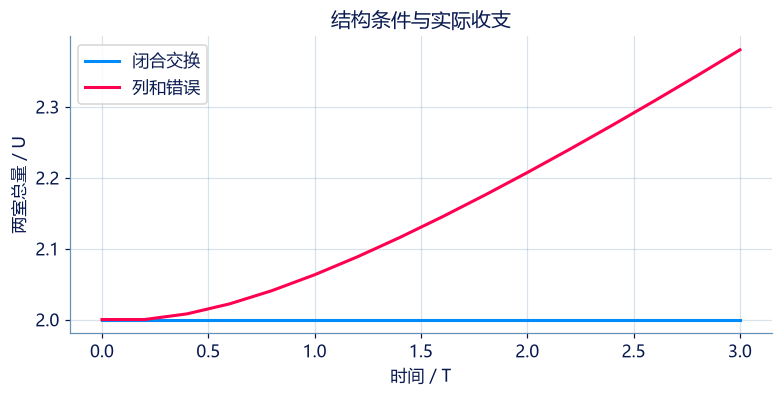

In [4]:
good=np.array([[-1.,.2],[1.,-.2]]);bad=np.array([[-1.,.3],[1.,-.2]]);negative=np.array([[-1.,-.2],[1.,.2]])
for name,A in [('闭合交换',good),('列和错误',bad),('负转移',negative)]:print(name,structure_metrics(A,.2))
x0=np.array([2.,0.]);times=np.arange(16)*.2
fig,ax=plt.subplots(figsize=(7,3.5))
for label,A,color in [('闭合交换',good,BLUE),('列和错误',bad,PINK)]:
    path=np.asarray(linear_roll(np.eye(2)+.2*A,x0,15));ax.plot(times,path.sum(axis=1),label=label,color=color)
ax.set(xlabel='时间 / T',ylabel='两室总量 / U',title='结构条件与实际收支');ax.grid(alpha=.25);ax.legend();plt.show()

## 结果解释

列和错误的候选把物质凭空加入系统；负的非对角项不满足任意非负初态的正性条件。即便连续矩阵正确，过大的 Euler 步也可能制造负值；结构误差与数值误差（numerical error）需要分开。

### 独立核对

手算第一列和与一步更新，核对闭合条件、坏矩阵的失效和大步长反例。

In [5]:
assert structure_metrics(good,.2)[3:] == [True,True]
assert structure_metrics(bad,.2)[3] is False
assert structure_metrics(negative,.2)[4] is False
assert structure_metrics(good,2.)[4] is False
np.testing.assert_allclose((np.eye(2)+.2*good)@x0,[1.6,.4])
print('列和、正性与 Euler 步长核验通过。')

列和、正性与 Euler 步长核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/explore/)，再返回此处核对完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：检查交换矩阵与 Euler 一步

状态（state）为各室总量，方程 dx/dt=operator·x。返回列和最大偏差、最小非对角元、最小 Euler 对角元，以及连续闭合交换条件和 Euler 非负条件的布尔值。

**函数与代码模板**

```python
def solve(
    operator: list[list[float]],
    dt: float,
) -> tuple[float, float, float, bool, bool]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `operator` | `list[list[float]]` | n×n 连续时间线性矩阵（matrix）。 | 1/T |
| `dt` | `float` | 正 Euler 步长。 | T |

**返回值**

按以下顺序返回元组：(max_balance, min_offdiag, min_euler_diag, closed_exchange, euler_nonnegative)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `max_balance` | `float` | 各列和绝对值最大值。 | 1/T |
| `min_offdiag` | `float` | 最小非对角元；n=1 时定义为0。 | 1/T |
| `min_euler_diag` | `float` | 最小的 1+dt·A_ii。 | 1 |
| `closed_exchange` | `bool` | 列和误差<10⁻¹⁰且非对角元≥−10⁻¹⁰。 | 1 |
| `euler_nonnegative` | `bool` | 非对角元≥−10⁻¹⁰且 Euler 对角元≥−10⁻¹⁰。 | 1 |

**计算规则**

按总量坐标检查列和。euler_nonnegative 只判一步矩阵是否逐项非负；它与 closed_exchange 分别报告。

**约束与边界**

- n≥1，operator 为 n×n 有限矩阵，dt>0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| operator | n×n 连续时间线性矩阵（matrix）。 | [[-1.0, 0.2], [1.0, -0.2]] | 1/T |
| dt | 正 Euler 步长。 | 0.2 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
operator = [[-1.0, 0.2], [1.0, -0.2]]
dt = 0.2

result = solve(operator, dt)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| max_balance | 各列和绝对值最大值。 | 0 | 1/T |
| min_offdiag | 最小非对角元；n=1 时定义为0。 | 0.2 | 1/T |
| min_euler_diag | 最小的 1+dt·A_ii。 | 0.8 | 1 |
| closed_exchange | 列和误差<10⁻¹⁰且非对角元≥−10⁻¹⁰。 | True | 1 |
| euler_nonnegative | 非对角元≥−10⁻¹⁰且 Euler 对角元≥−10⁻¹⁰。 | True | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.0, 0.2, 0.8, True, True)
```

**样例解释**

首例列和为零、非对角元非负，且一步 Euler 的最小对角为0.8；两种布尔检查都成立。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：检查交换矩阵与 Euler 一步](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/practice/?question=p14-structure-metrics)

### 第 2 题 · 单项选择题：总量守恒看哪一项

状态（state）是各室总量，dx/dt=A x。要求所有初态的总量守恒，应检查什么？

- **A.** A 的每列和为0。
- **B.** A 的每行和为0 就足够。
- **C.** 只看某一条轨迹（trajectory）总量不变。
- **D.** 只看 A 的迹为0。

[作答：总量守恒看哪一项](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/practice/?question=p14-column-conservation)

### 第 3 题 · 单项选择题：连续正性与一步正性

连续闭合交换矩阵（matrix）符合非对角元非负，过大的显式 Euler 步长还可能造成什么？

- **A.** 一步矩阵对角元为负，非负初态出现负分量。
- **B.** 连续模型（model）立即失去守恒。
- **C.** 列和必随 h 改变成非零。
- **D.** 算法自动改用隐式 Euler。

[作答：连续正性与一步正性](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/practice/?question=p14-euler-positive)

### 第 4 题 · 单项选择题：何时不能照搬列和

同一个交换过程改用不同容积的浓度（concentration）作为状态（state），哪项做法正确？

- **A.** 从总量=容积×浓度重新推导权重守恒条件。
- **B.** 继续要求浓度状态矩阵（matrix）普通列和为0。
- **C.** 浓度必等于总量。
- **D.** 改变量名就保持全部判据不变。

[作答：何时不能照搬列和](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/practice/?question=p14-concentration-coordinates)

**进一步阅读**

[第 11 篇网络扩散](../../../docs/11-网络上的系统.md)给出同类守恒机制；本节只检查无输入总量坐标。